<img src="./logo_UTN.svg" align="right" width="150" />

# Tarea Semanal 6

*Alumno: Lapilli Cañedo, Mariano Adrian*

# Consigna

A continuación se muestran 2 circuitos conocidos en un esquema de 3 nodos externos.  Tener en cuenta que para el análisis de la red se pueden definir nodos internos.

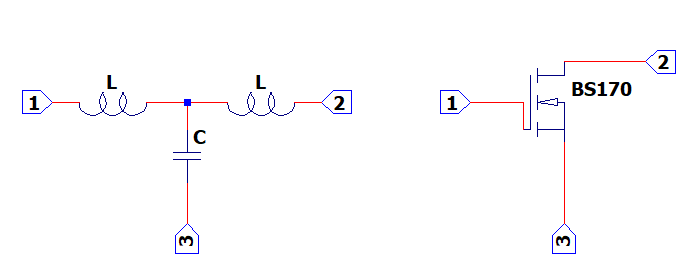

Se pide:

1. Construir la Matriz Admitancia Indefinida para cada caso. En el BS170 plantear el modelo lineal visto en clase con admitancias y generadores de corriente, que tenga en cuenta: $C_{iss}$, $C_{oss}$, $C_{rss}$ y $g_m$ 
   

2. Para la red T se pide:

     a ) Obtener $\frac{V_{23}}{V_{13}}$ ; $\frac{V_{21}}{V_{31}}$ y $\frac{V_{12}}{V_{32}}$, explicitando el armado de los cofactores de segundo orden.      

     b ) Graficar y observar detenidamente la respuesta de módulo y fase para cada transferencia. Analizar si entre 2 de las transferencias halladas se cumple que son complementarias en módulo :| $T_a$ + $T_b$ | =  1   

3. Para el MOS se pide:

     a ) Dada la MAI hallada en 1 obtener los parámetros $Y$ para las configuraciones source común y drain común. 

     b ) Calcular la matriz de parámetros $ABCD$ en configuración source común.


Propiedades de la MAI:   

La sumatoria de filas es igual a cero.
La sumatoria de columnas es igual a cero.
El determinante de la matriz es igual a cero.
Todos los cofactores de primer orden son iguales, es decir:  $Y^{i}_{j} = Y^{n}_{m}$


## Bonus

💎 Implementar en Python el armado de la MAI y la obtención de 2a) con los módulos disponibles en pytc2 

🥉 Simulación Circuital y medición de los parámetros 
  del MOS en configuración drain común. Implementar el modelo SPICE del BS170:

.MODEL BS170 NMOS (

+ VTO=1.824 

+ KP=0.123 

+ LAMBDA=0.012 

+ RD=1.2 

+ RS=1.2 

+ RG=10 

+ CBD=18p 

+ CBS=0 

+ CJ=0 

+ CJO=24p 

+ CGSO=30p 

+ CGDO=10p 

+ IS=1e-14 

+ PB=0.8 

+ MJ=0.5 

+ FC=0.5

+)



*-------------------------------------------------------------------

* BS170 SPICE Model (Vishay / Siliconix)

* Includes non-linear Ciss, Coss, Crss capacitances & Body Diode

* Node 1: Drain (D) | Node 2: Gate (G) | Node 3: Source (S)

*-------------------------------------------------------------------

.SUBCKT BS170 1 2 3

M1 9 7 8 8 MM L=10u W=30u

D1 8 1 D_BODY

RG 2 7 10

RD 1 9 1.15

RS 3 8 0.15

CGS 7 8 24.5p

CGD 7 1 3.5p

DBODY 8 1 D_BD

.MODEL MM NMOS (

+ LEVEL = 3

+ VTO   = 2.1

+ KP    = 0.38

+ THETA = 0.08

+ VMAX  = 1.5e5

+ ETA   = 0.015

+)

.MODEL D_BODY D (

+ IS    = 1e-13

+ RS    = 0.1

+ N     = 1.0

+ BV    = 60

+ IBV   = 10u

+)

.MODEL D_BD D (

+ IS    = 1e-15

+ CJO   = 28p

+ VJ    = 0.8

+ M     = 0.5

+)


.ENDS BS170


In [2]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti

# Resolución

## Item 1

Adjunto mi resolución hecha en el pizarrón para ambas redes:

<img src="./resuitem1.jpg" align="center" width=1000 />

### Observación: Para la red T debo considerar el nodo en el que convergen las tres admitancias, de esa forma puedo armar la matriz. En caso contrario quedarían todos los elementos iguales en la matriz.

## Item 2

Adjunto mi resolución hecha en el pizarrón de los sub-items a y b:

<img src="./resuitem21.jpg" align="center" width=1000 />

<img src="./resuitem22.jpg" align="center" width=1000 />

<img src="./resuitem23.jpg" align="center" width=1000 />



/home/mariano/marianoTC2/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


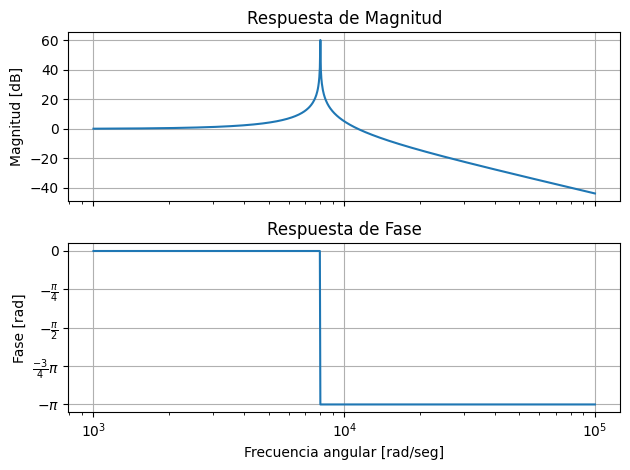

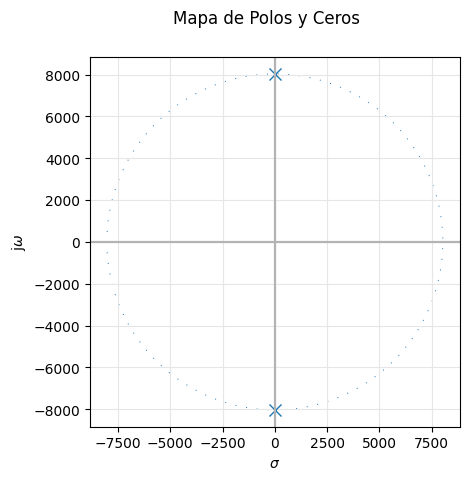

In [3]:
#Simulación de V23/V13 

L = 47e-3
C = 330e-9

num = [0, 0, 1]
den = [L * C, 0, 1]

H = sig.TransferFunction(num, den)

_, axes_hdl = bodePlot(H)

plt.tight_layout()
pzmap(H)
plt.show()

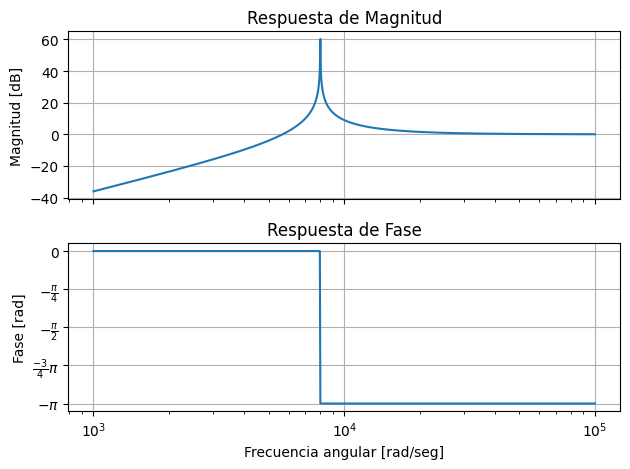

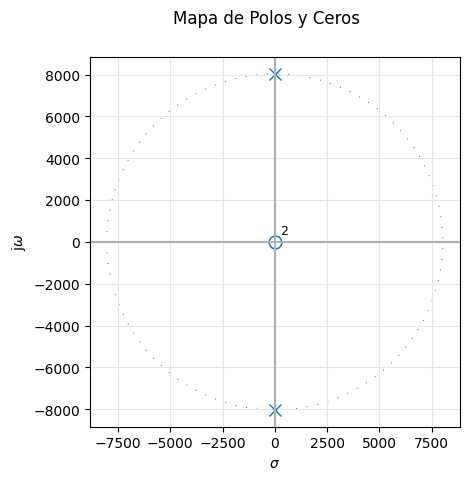

In [7]:
#Simulación de V21/V32 

L = 47e-3
C = 330e-9

num = [ - (L * C), 0, 0]
den = [L * C, 0, 1]

H = sig.TransferFunction(num, den)

_, axes_hdl = bodePlot(H)

plt.tight_layout()
pzmap(H)
plt.show()

### Se verifica |$T_a$ + $T_b$| = 1 para  $\frac{V_{23}}{V_{13}}$ y $\frac{V_{21}}{V_{31}}$ ó $\frac{V_{12}}{V_{32}}$